# Data Analysis - 2nd Part

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import matplotlib.image as mpimg

### Classification


In [8]:
# Load the cleaned NHIS 2024 adult survey dataset
clean_nhis = pd.read_csv('data/02-processed/nhis_2024_sample_adult_cleaned.csv')

# Work on a copy to preserve the original cleaned data
df_ML = clean_nhis.copy()

# Construct a composite access disruption score (0–5) by summing binary indicators:
# each condition contributes 1 point if the respondent experienced that barrier
df_ML['access_disruption_score'] = (
    (df_ML['delayed_medical_care'] == 1).astype(int)          # delayed care due to cost/access
    + (df_ML['usual_place_care'] != 'Has usual place of care').astype(int)  # no usual care site
    + (df_ML['any_er_visit'] >= 1).astype(int)                # ≥1 ER visit (proxy for unmet primary care)
    + (df_ML['doctor_gap_yr'] > 1).astype(int)                # >1 year since last doctor visit
    + (df_ML['general_health'] <= 2).astype(int)              # poor/fair self-reported health
)

# Drop raw government rent assistance column (will be re-encoded below)
df_ML = df_ML.drop(columns=['government_rent_assistance'])

# Rename NHIS variable codes to human-readable column names
df_ML = df_ML.rename(columns={'AGEP_A': 'age', 'POVRATTC_A': 'poverty_ratio'})


In [10]:
# Re-encode rent assistance as a labeled categorical from the original column
# -1 = not applicable, 0 = No, 1 = Yes
df_ML['government_rent_assistance_cat'] = clean_nhis['government_rent_assistance'].map({
    -1: 'not applicable', 0: 'No', 1: 'yes'
})

# Binarize health insurance status: Uninsured → 0, Insured → 1
df_ML['health_insurance'] = clean_nhis['health_insurance'].map({
    'Uninsured': 0,
    'Insured': 1
})

# Drop survey design variables (HHX = household ID, WTFA_A = sample weight,
# PSTRAT/PPSU = stratification/PSU for complex survey design),
# and the raw component columns that were rolled into the disruption score
X = df_ML.drop(columns=[
    'HHX', 'WTFA_A', 'PSTRAT', 'PPSU',
    'usual_place_care', 'general_health', 'delayed_medical_care',
    'any_er_visit', 'doctor_gap_yr',
    'access_disruption_score'   # target variable — must not be a feature
])

# Target: predict each respondent's access disruption score (0–5)
y = df_ML['access_disruption_score']

# Survey weights (extracted for potential use in weighted evaluation)
w = df_ML["WTFA_A"]

# Stratified 80/20 train-test split — stratify ensures each score class
# is proportionally represented in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Identify numeric vs. categorical columns for separate preprocessing
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

In [11]:
# Standardize numeric features to zero mean and unit variance
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

# One-hot encode categoricals; ignore categories unseen at test time
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Apply the appropriate transformer to each column group
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# Full modeling pipeline: preprocess → Logistic Regression classifier
# max_iter=5000 to ensure convergence on this multi-class problem
model = Pipeline([
    ('prep', preprocessor),
    ('svm', LogisticRegression(max_iter=5000))   # note: mislabeled 'svm'; this is logistic regression
])

In [12]:
# Fit on training data (preprocessing is applied internally by the pipeline)
model.fit(X_train, y_train)

# Generate predicted disruption scores on the held-out test set
y_pred = model.predict(X_test)

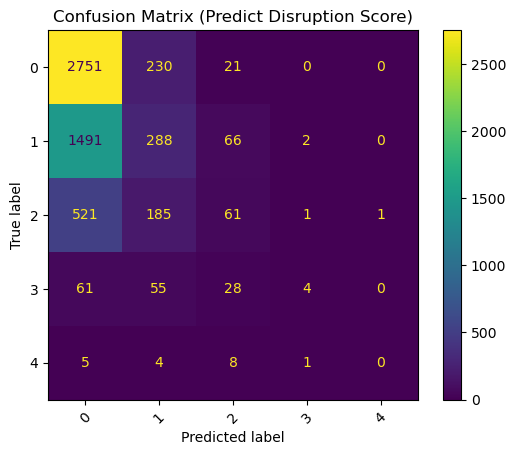

In [13]:
# Collect all class labels present in either ground truth or predictions
class_names = np.unique(np.concatenate((y_test, y_pred)))

# Build and display confusion matrix; rows = true score, columns = predicted score
conf_mat = confusion_matrix(y_test, y_pred)
mat = ConfusionMatrixDisplay(
    conf_mat,
    display_labels=class_names
).plot()
plt.xticks(rotation=45)
plt.title("Confusion Matrix (Predict Disruption Score)")

# Save high-res confusion matrix figure
mat.figure_.savefig('results/classification_confusion_matrix.png', dpi=200)

# Generate per-class precision/recall/F1 report and export to CSV
report = classification_report(y_test, y_pred, output_dict=True)
rep_df = pd.DataFrame.from_dict(report)
rep_df.to_csv('results/classification_report.csv', index=True)

### Count Model: Healthcare Access Disruption Score


In [14]:
from pathlib import Path
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display

# Work on a copy of the cleaned NHIS data to avoid modifying the original
analysis_data = clean_nhis.copy()

# Reconstruct the same composite access disruption score (0–5) used in the
# classification analysis — each binary condition contributes 1 point
analysis_data['access_disruption_score'] = (
    (analysis_data['delayed_medical_care'] == 1).astype(int)         # delayed care due to cost/access
    + (analysis_data['usual_place_care'] != 'Has usual place of care').astype(int)  # no usual care site
    + (analysis_data['any_er_visit'] >= 1).astype(int)               # ≥1 ER visit (proxy for unmet primary care)
    + (analysis_data['doctor_gap_yr'] > 1).astype(int)               # >1 year since last doctor visit
    + (analysis_data['general_health'] <= 2).astype(int)             # poor/fair self-reported health
)

# Tabulate how many respondents fall into each score level (0–5)
score_distribution = (
    analysis_data['access_disruption_score']
    .value_counts()
    .sort_index()
    .to_frame('n')
)
# Add column-percent so the distribution is easy to interpret
score_distribution['percent'] = score_distribution['n'] / score_distribution['n'].sum() * 100

# Summarize the score's central tendency and spread
distribution_summary = pd.DataFrame({
    'mean':     [analysis_data['access_disruption_score'].mean()],
    'variance': [analysis_data['access_disruption_score'].var()],
    'min':      [analysis_data['access_disruption_score'].min()],
    'max':      [analysis_data['access_disruption_score'].max()]
})

# Persist distribution outputs for reporting
score_distribution.to_csv('results/access_disruption_score_distribution.csv', index=True)
distribution_summary.to_csv('results/access_disruption_score_summary.csv', index=False)

In [15]:
# --- Model 1: Full-sample Poisson GLM ---
# Predicts disruption score from SDOH predictors + demographic controls.
# Housing tenure uses homeowners as the reference category.
# HC1 robust SEs guard against heteroskedasticity in the count outcome.
full_formula = '''access_disruption_score ~ transportation_barrier + housing_cost_trouble
+ C(housing_tenure, Treatment(reference="Owned or being bought"))
+ AGEP_A + POVRATTC_A
+ C(sex) + C(race_ethnicity) + C(education) + C(health_insurance)'''

full_model = smf.glm(
    formula=full_formula,
    data=analysis_data,
    family=sm.families.Poisson()   # log-link; coefficients are log IRRs
).fit(cov_type='HC1')              # heteroskedasticity-robust standard errors

# --- Model 2: Renter-only Poisson GLM ---
# Subset to renters so government_rent_assistance can be included as a predictor
# (it is collinear with housing tenure in the full sample and thus dropped there)
renters = analysis_data[analysis_data['housing_tenure'] == 'Rented'].copy()

renter_formula = '''access_disruption_score ~ transportation_barrier + housing_cost_trouble
+ government_rent_assistance + AGEP_A + POVRATTC_A
+ C(sex) + C(race_ethnicity) + C(education) + C(health_insurance)'''

renter_model = smf.glm(
    formula=renter_formula,
    data=renters,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

# --- IRR table helper ---
def make_irr_table(result, model_name):
    """
    Convert a fitted GLM result into a tidy dataframe of incidence rate ratios.

    Exponentiates coefficients and their confidence intervals so they are
    interpretable as multiplicative effects on the expected disruption score.

    Parameters
    ----------
    result : statsmodels GLM result object
    model_name : str  — label attached to every row for identification

    Returns
    -------
    pd.DataFrame with columns: model, term, coef, IRR, CI_lower, CI_upper, p_value
    """
    conf = result.conf_int()   # 95% CIs on the log scale
    table = pd.DataFrame({
        'model':    model_name,
        'term':     result.params.index,
        'coef':     result.params.values,          # log IRR
        'IRR':      np.exp(result.params.values),  # exponentiated → IRR
        'CI_lower': np.exp(conf[0].values),
        'CI_upper': np.exp(conf[1].values),
        'p_value':  result.pvalues.values
    })
    return table

# Build IRR tables for both models and stack them for joint export
full_results   = make_irr_table(full_model,   'Full sample Poisson')
renter_results = make_irr_table(renter_model, 'Renter-only Poisson')
poisson_results = pd.concat([full_results, renter_results], ignore_index=True)

# Isolate only the focal SDOH predictors for the summary table and forest plot;
# demographic controls are retained in the full results file but not highlighted
key_terms = [
    'transportation_barrier',
    'housing_cost_trouble',
    'C(housing_tenure, Treatment(reference="Owned or being bought"))[T.Rented]',
    'C(housing_tenure, Treatment(reference="Owned or being bought"))[T.Other arrangement]',
    'government_rent_assistance'
]
key_results = poisson_results[poisson_results['term'].isin(key_terms)].copy()

# Ensure results directory exists, then export
Path('results').mkdir(exist_ok=True)
poisson_results.to_csv('results/access_disruption_poisson_results.csv', index=False)
key_results.to_csv('results/access_disruption_poisson_key_results.csv', index=False)


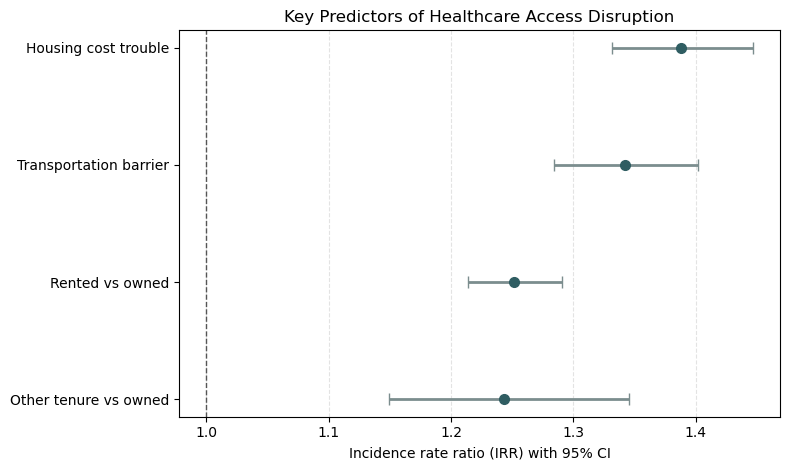

In [16]:
# --- Forest plot ---
import matplotlib.pyplot as plt

# Re-read from disk so the plot is reproducible independently of the session state
key_results_for_plot = pd.read_csv('results/access_disruption_poisson_key_results.csv')

# Subset to full-sample model only (renter-only results have a different predictor set)
forest_data = key_results_for_plot[
    key_results_for_plot['model'] == 'Full sample Poisson'
].copy()

# Map statsmodels term strings to clean display labels
label_map = {
    'transportation_barrier': 'Transportation barrier',
    'housing_cost_trouble':   'Housing cost trouble',
    'C(housing_tenure, Treatment(reference="Owned or being bought"))[T.Rented]':            'Rented vs owned',
    'C(housing_tenure, Treatment(reference="Owned or being bought"))[T.Other arrangement]': 'Other tenure vs owned'
}
forest_data['label'] = forest_data['term'].map(label_map)

# Drop any terms without a label (e.g. if government_rent_assistance slips in)
# and sort ascending by IRR so the largest effect plots at the top
forest_data = forest_data.dropna(subset=['label']).sort_values('IRR')

fig, ax = plt.subplots(figsize=(8, 4.8))
y_pos = np.arange(len(forest_data))

# Horizontal error bars: center = IRR, whiskers = asymmetric 95% CI
ax.errorbar(
    forest_data['IRR'],
    y_pos,
    xerr=[
        forest_data['IRR'] - forest_data['CI_lower'],  # left whisker length
        forest_data['CI_upper'] - forest_data['IRR']   # right whisker length
    ],
    fmt='o',
    color='#2F5D62',    # point color
    ecolor='#7B8D8E',   # whisker color
    elinewidth=2,
    capsize=4,
    markersize=7
)

# Reference line at IRR = 1 (null effect)
ax.axvline(1, color='#555555', linestyle='--', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_data['label'])
ax.set_xlabel('Incidence rate ratio (IRR) with 95% CI')
ax.set_title('Key Predictors of Healthcare Access Disruption')
ax.grid(axis='x', linestyle='--', alpha=0.35)

fig.tight_layout()
fig.savefig('results/access_disruption_irr_forest_plot.png', dpi=200)
plt.show()

### Additional Analyses Addressing Specific Aspects of the Outcomes

In [18]:
# Reusable RHS formula strings — shared across all models in this script
# to ensure every outcome is modeled with identical predictors

# Full sample: housing tenure included (homeowners = reference)
full_rhs = '''transportation_barrier + housing_cost_trouble
+ C(housing_tenure, Treatment(reference="Owned or being bought"))
+ AGEP_A + POVRATTC_A
+ C(sex) + C(race_ethnicity) + C(education) + C(health_insurance)'''

# Renter-only: tenure dropped (no variation), government_rent_assistance added
renter_rhs = '''transportation_barrier + housing_cost_trouble
+ government_rent_assistance + AGEP_A + POVRATTC_A
+ C(sex) + C(race_ethnicity) + C(education) + C(health_insurance)'''


def make_or_table(result, model_name):
    """
    Convert a fitted Binomial GLM result into a tidy odds-ratio table.

    Exponentiates coefficients and CIs so they are interpretable as
    multiplicative effects on the odds of the binary outcome.
    The intercept is dropped since it has no substantive interpretation here.

    Parameters
    ----------
    result : statsmodels GLM result object
    model_name : str — label attached to every row for identification

    Returns
    -------
    pd.DataFrame with columns: model, term, OR, CI_lower, CI_upper, p_value
    """
    params = result.params
    conf   = result.conf_int()
    return (
        pd.DataFrame({
            'model':    model_name,
            'term':     params.index,
            'OR':       np.exp(params),        # exponentiated log-odds → OR
            'CI_lower': np.exp(conf[0]),
            'CI_upper': np.exp(conf[1]),
            'p_value':  result.pvalues
        })
        .query("term != 'Intercept'")          # drop intercept row
        .round({'OR': 4, 'CI_lower': 4, 'CI_upper': 4, 'p_value': 4})
    )


# Work on a copy to preserve the original cleaned data
aspect_data = clean_nhis.copy()

# Binarize usual_place_care for use as a logistic regression outcome
# (1 = has a usual place of care, 0 = does not)
aspect_data['has_usual_place'] = (
    aspect_data['usual_place_care'] == 'Has usual place of care'
).astype(int)

# Renter subset used across all renter-only models below
renters = aspect_data[aspect_data['housing_tenure'] == 'Rented'].copy()


# ── Outcome 1: Delayed medical care (binary) ─────────────────────────────────
# Logistic regression (Binomial GLM); OR > 1 means higher odds of delaying care

delay_full = smf.glm(
    formula='delayed_medical_care ~ ' + full_rhs,
    data=aspect_data,
    family=sm.families.Binomial()
).fit(cov_type='HC1')

delay_renter = smf.glm(
    formula='delayed_medical_care ~ ' + renter_rhs,
    data=renters,
    family=sm.families.Binomial()
).fit(cov_type='HC1')

delay_results = pd.concat([
    make_or_table(delay_full,   'Full sample Logistic – delayed_medical_care'),
    make_or_table(delay_renter, 'Renter-only Logistic – delayed_medical_care')
], ignore_index=True)


# ── Outcome 2: Has a usual place of care (binary) ────────────────────────────
# OR > 1 means higher odds of having a usual care site (protective direction)

usual_full = smf.glm(
    formula='has_usual_place ~ ' + full_rhs,
    data=aspect_data,
    family=sm.families.Binomial()
).fit(cov_type='HC1')

usual_renter = smf.glm(
    formula='has_usual_place ~ ' + renter_rhs,
    data=renters,
    family=sm.families.Binomial()
).fit(cov_type='HC1')

usual_results = pd.concat([
    make_or_table(usual_full,   'Full sample Logistic – has_usual_place'),
    make_or_table(usual_renter, 'Renter-only Logistic – has_usual_place')
], ignore_index=True)


# ── Outcome 3: Years since last doctor visit (count) ─────────────────────────
# Poisson GLM; IRR > 1 means longer gap since last visit

doctor_full = smf.glm(
    formula='doctor_gap_yr ~ ' + full_rhs,
    data=aspect_data,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

doctor_renter = smf.glm(
    formula='doctor_gap_yr ~ ' + renter_rhs,
    data=renters,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

doctor_results = pd.concat([
    make_irr_table(doctor_full,   'Full sample Poisson – doctor_gap_yr'),
    make_irr_table(doctor_renter, 'Renter-only Poisson – doctor_gap_yr')
], ignore_index=True)


# ── Outcome 4: Any ER visit in past year (count) ──────────────────────────────
# Poisson GLM; IRR > 1 means more ER utilization (proxy for unmet primary care)

er_full = smf.glm(
    formula='any_er_visit ~ ' + full_rhs,
    data=aspect_data,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

er_renter = smf.glm(
    formula='any_er_visit ~ ' + renter_rhs,
    data=renters,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

er_results = pd.concat([
    make_irr_table(er_full,   'Full sample Poisson – any_er_visit'),
    make_irr_table(er_renter, 'Renter-only Poisson – any_er_visit')
], ignore_index=True)


# ── Outcome 5: Self-reported general health (ordered count, 1–5) ──────────────
# Treated as a count here via Poisson; IRR > 1 means better self-rated health
# Note: lower raw scores = worse health in NHIS coding, so interpret direction carefully

health_full = smf.glm(
    formula='general_health ~ ' + full_rhs,
    data=aspect_data,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

health_renter = smf.glm(
    formula='general_health ~ ' + renter_rhs,
    data=renters,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

health_results = pd.concat([
    make_irr_table(health_full,   'Full sample Poisson – general_health'),
    make_irr_table(health_renter, 'Renter-only Poisson – general_health')
], ignore_index=True)


# ── Export per-outcome results ────────────────────────────────────────────────
delay_results.to_csv('results/aspect_delayed_medical_care.csv', index=False)
usual_results.to_csv('results/aspect_usual_place_care.csv',     index=False)
doctor_results.to_csv('results/aspect_doctor_gap_yr.csv',       index=False)
er_results.to_csv('results/aspect_any_er_visit.csv',            index=False)
health_results.to_csv('results/aspect_general_health.csv',      index=False)

# Stack all five outcomes into a single long-format results table
all_aspect_results = pd.concat([
    delay_results,
    usual_results,
    doctor_results,
    er_results,
    health_results
], ignore_index=True)

# Filter to the focal SDOH predictors defined in key_terms (from the main analysis)
all_aspect_key_results = all_aspect_results[
    all_aspect_results['term'].isin(key_terms)
].copy()

# Export combined results — full for archiving, key for reporting
all_aspect_results.to_csv('results/aspect_all_results.csv',     index=False)
all_aspect_key_results.to_csv('results/aspect_key_results.csv', index=False)

## Stratified by Race Ethnicity

In [19]:
# ── Non-white subsample Poisson models ───────────────────────────────────────

# Subset to all respondents who are not White non-Hispanic to examine whether
# SDOH barrier effects hold within racially minoritized groups
not_white = analysis_data[analysis_data['race_ethnicity'] != 'White non-Hispanic'].copy()

# Full-sample (non-white) Poisson GLM using the same formula as the main analysis
not_white_model = smf.glm(
    formula=full_formula,
    data=not_white,
    family=sm.families.Poisson()
).fit(cov_type='HC1')   # HC1 robust SEs for heteroskedasticity

# Further subset to renters within the non-white group for the rent-assistance analysis
nonwhite_renters = not_white[not_white['housing_tenure'] == 'Rented'].copy()

# Renter-only Poisson GLM within the non-white subsample
nonwhite_renter_model = smf.glm(
    formula=renter_formula,
    data=nonwhite_renters,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

# Convert coefficients to IRRs and stack both non-white model results
not_white_results      = make_irr_table(not_white_model,      'Non-white subsample')
nonwhite_renter_results = make_irr_table(nonwhite_renter_model, 'Nonwhite_renter-only Poisson')
poisson_results = pd.concat([not_white_results, nonwhite_renter_results], ignore_index=True)

# Filter to focal SDOH predictors (defined in key_terms from the main analysis)
key_results = poisson_results[poisson_results['term'].isin(key_terms)].copy()

# Persist full and key results for the non-white subsample
Path('results').mkdir(exist_ok=True)
poisson_results.to_csv('results/access_non-white_subsample_poisson_results.csv', index=False)
key_results.to_csv('results/access_non-white_subsample_key_poisson_results.csv', index=False)


## Poisson Prediction

In [21]:
# Seeded RNG for reproducible train/test split (used below instead of sklearn)
rng = np.random.default_rng(108)

# Work on a copy to avoid modifying the shared cleaned dataset
prediction_data = clean_nhis.copy()

# Reconstruct the same composite access disruption score (0–5) used throughout
prediction_data['access_disruption_score'] = (
    (prediction_data['delayed_medical_care'] == 1).astype(int)
    + (prediction_data['usual_place_care'] != 'Has usual place of care').astype(int)
    + (prediction_data['any_er_visit'] >= 1).astype(int)
    + (prediction_data['doctor_gap_yr'] > 1).astype(int)
    + (prediction_data['general_health'] <= 2).astype(int)
)
# composite count outcome (0–5); higher = greater disruption

# Same predictor set as the main Poisson analysis
prediction_formula = '''access_disruption_score ~ transportation_barrier + housing_cost_trouble
+ C(housing_tenure, Treatment(reference="Owned or being bought"))
+ AGEP_A + POVRATTC_A
+ C(sex) + C(race_ethnicity) + C(education) + C(health_insurance)'''

# Random 80/20 train/test split via boolean mask (no stratification here,
# unlike the sklearn split in the classification notebook)
train_mask = rng.random(len(prediction_data)) < 0.8
train_data = prediction_data.loc[train_mask].copy()
test_data  = prediction_data.loc[~train_mask].copy()

# Fit Poisson GLM on training set only — used purely for out-of-sample evaluation
prediction_model = smf.glm(
    formula=prediction_formula,
    data=train_data,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

# Generate predicted disruption scores on the held-out test set
test_data['predicted_access_disruption_score'] = prediction_model.predict(test_data)

# Compare model performance against a naive baseline that always predicts the
# training-set mean — if the model doesn't beat this, it isn't useful
prediction_performance = pd.DataFrame({
    'model': ['Poisson GLM', 'Train-mean baseline'],
    'MAE': [
        np.mean(np.abs(test_data['access_disruption_score'] - test_data['predicted_access_disruption_score'])),
        np.mean(np.abs(test_data['access_disruption_score'] - train_data['access_disruption_score'].mean()))
    ],
    'RMSE': [
        np.sqrt(np.mean((test_data['access_disruption_score'] - test_data['predicted_access_disruption_score']) ** 2)),
        np.sqrt(np.mean((test_data['access_disruption_score'] - train_data['access_disruption_score'].mean()) ** 2))
    ],
    'test_n': [len(test_data), len(test_data)]
})

# Refit on the full dataset to get more stable coefficient estimates;
# this model is used for scenario predictions below, not for evaluation
full_prediction_model = smf.glm(
    formula=prediction_formula,
    data=prediction_data,
    family=sm.families.Poisson()
).fit(cov_type='HC1')

def mode_value(series):
    """Return the most frequent non-null value in a series."""
    return series.mode(dropna=True).iloc[0]

# Construct a "typical" reference person: homeowner, no SDOH barriers,
# median age and poverty ratio, modal values for all categorical demographics
baseline_person = {
    'transportation_barrier': 0.0,
    'housing_cost_trouble':   0.0,
    'housing_tenure':         'Owned or being bought',
    'AGEP_A':                 prediction_data['AGEP_A'].median(),
    'POVRATTC_A':             prediction_data['POVRATTC_A'].median(),
    'sex':                    mode_value(prediction_data['sex']),
    'race_ethnicity':         mode_value(prediction_data['race_ethnicity']),
    'education':              mode_value(prediction_data['education']),
    'health_insurance':       mode_value(prediction_data['health_insurance'])
}

# Six counterfactual profiles that vary only the key SDOH predictors
# (transportation barrier, housing cost trouble, housing tenure);
# all other attributes are held fixed at the baseline values above
scenario_specs = [
    ('No transportation or housing barrier',     0.0, 0.0, 'Owned or being bought'),
    ('Transportation barrier only',              1.0, 0.0, 'Owned or being bought'),
    ('Housing cost trouble only',                0.0, 1.0, 'Owned or being bought'),
    ('Both transportation and housing barriers', 1.0, 1.0, 'Owned or being bought'),
    ('Renter, no listed barrier',                0.0, 0.0, 'Rented'),
    ('Renter with both barriers',                1.0, 1.0, 'Rented')
]

# Build one row per scenario by layering barrier/tenure values onto the baseline
scenario_rows = []
for scenario, transportation, housing_trouble, tenure in scenario_specs:
    row = baseline_person.copy()
    row.update({
        'scenario':              scenario,
        'transportation_barrier': transportation,
        'housing_cost_trouble':   housing_trouble,
        'housing_tenure':         tenure
    })
    scenario_rows.append(row)

scenario_predictions = pd.DataFrame(scenario_rows)

# Predict expected disruption score for each counterfactual profile
scenario_predictions['predicted_access_disruption_score'] = (
    full_prediction_model.predict(scenario_predictions)
)

# Compute absolute and relative difference vs. the no-barrier baseline (row 0)
scenario_predictions['increase_vs_baseline'] = (
    scenario_predictions['predicted_access_disruption_score']
    - scenario_predictions.loc[0, 'predicted_access_disruption_score']
)
scenario_predictions['percent_increase_vs_baseline'] = (
    scenario_predictions['increase_vs_baseline']
    / scenario_predictions.loc[0, 'predicted_access_disruption_score']
    * 100
)

# ── Export results ────────────────────────────────────────────────────────────
Path('results').mkdir(exist_ok=True)

# Model evaluation metrics vs. naive baseline
prediction_performance.to_csv(
    'results/access_disruption_prediction_performance.csv', index=False
)

# Scenario predictions (drop non-essential baseline demographic columns)
scenario_predictions[[
    'scenario', 'transportation_barrier', 'housing_cost_trouble', 'housing_tenure',
    'predicted_access_disruption_score', 'increase_vs_baseline', 'percent_increase_vs_baseline'
]].to_csv('results/access_disruption_scenario_predictions.csv', index=False)

# Individual test-set predictions for downstream diagnostics or plotting
test_data[['HHX', 'access_disruption_score', 'predicted_access_disruption_score']].to_csv(
    'results/access_disruption_test_predictions.csv', index=False
)

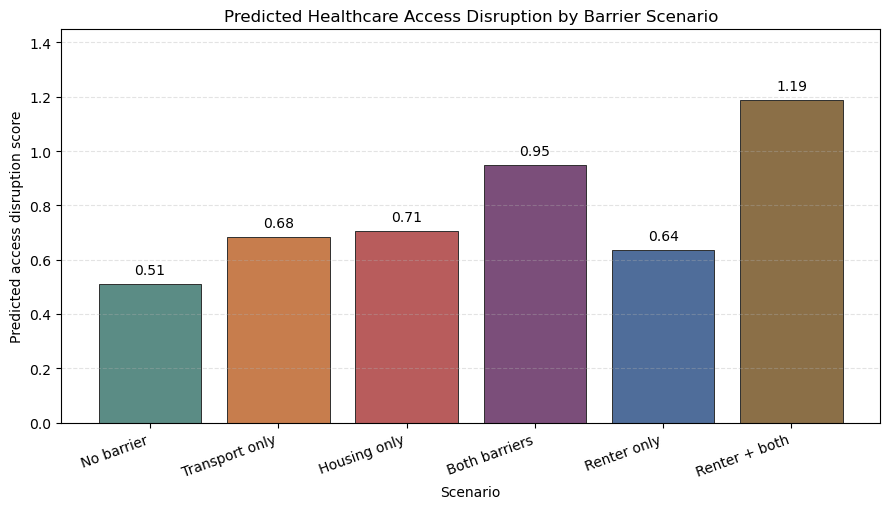

In [22]:
# Load the six counterfactual scenario predictions produced in the prediction script
scenario_predictions_for_plot = pd.read_csv('results/access_disruption_scenario_predictions.csv')

# Short display labels corresponding to the six scenarios (order must match CSV)
scenario_labels = [
    'No barrier',
    'Transport only',
    'Housing only',
    'Both barriers',
    'Renter only',
    'Renter + both'
]
scenario_predictions_for_plot['plot_label'] = scenario_labels

fig, ax = plt.subplots(figsize=(9, 5.2))

# One distinct color per scenario to make bars easy to tell apart
colors = ['#5B8C85', '#C77D4D', '#B85C5C', '#7B4E7A', '#4F6D9A', '#8B6F47']

bars = ax.bar(
    scenario_predictions_for_plot['plot_label'],
    scenario_predictions_for_plot['predicted_access_disruption_score'],
    color=colors,
    edgecolor='#2f2f2f',
    linewidth=0.7
)

# Annotate each bar with its predicted score value just above the bar top
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # center horizontally on the bar
        height + 0.025,                        # small vertical offset above bar
        f'{height:.2f}',
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_ylabel('Predicted access disruption score')
ax.set_xlabel('Scenario')
ax.set_title('Predicted Healthcare Access Disruption by Barrier Scenario')

# Add 22% headroom above the tallest bar so value labels don't clip
ax.set_ylim(0, max(scenario_predictions_for_plot['predicted_access_disruption_score']) * 1.22)

# Rotate x-tick labels and right-align them so they don't overlap
ax.tick_params(axis='x', rotation=20)
for label in ax.get_xticklabels():
    label.set_ha('right')

ax.grid(axis='y', linestyle='--', alpha=0.35)
fig.tight_layout()
fig.savefig('results/access_disruption_scenario_predictions.png', dpi=200)
plt.show()